# 06b — Surprise + Pattern: Does DTW Improve the Surprise Strategy? — ZN

## Purpose

The original project plan ends with a three-way comparison:

> **Surprise only** vs **Surprise + State** vs **Surprise + Pattern**

Notebooks 04 and 05 covered the first two. This notebook completes the third arm. It adds a **Dynamic Time Warping (DTW)** pattern signal, the method behind the peer strategy (Jack Duncan, Hoshea Zeng), to the surprise strategy of Notebook 05.

**Question:**

> Does the *shape* of the market's price path around a release add information beyond the *surprise* itself?

**Prior evidence (stated before running):** the team has tested DTW for **direction** many times. Jack's six designs, Hoshea's generalisation test and Aaryen's features at an executable entry all failed to establish a directional DTW edge. The expected result is therefore **no improvement**. This notebook is the first test of DTW **as a confirmation of the surprise**, with our executable entry, our universe and our evaluation.

**Credits:** the DTW specification (31-minute z-scored path, same clock slot, 3-year lookback, 600 most recent, k = 15, Sakoe-Chiba band 5, 1/distance × 2-year-half-life recency weights, middle-40% rank gate) is from the peer DTW strategy (**Jack Duncan, Hoshea Zeng**). The "reaction path" ending at T+1 is Jack's design 5.

> **06b — 10-year T-note futures (ZN).** This notebook is Notebook 06 (ES) run on **ZN**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_ZN.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **ZN** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the ZN contract (tick 1/64, $1,000 per point).
> - Outputs are saved as `nb06b_ZN_*` (results, figures), so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the ZN results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Load the Notebook 05 trade log (surprise strategies and the traded releases) |
| 3 | Rebuild the release calendar and ES price measures (as in Notebook 05) |
| 4 | Build the DTW signal for every release (walk-forward, history only) |
| 5 | Diagnostics: does DTW predict the 30-minute return? Is it related to the surprise? |
| 6 | Strategies: DTW only, surprise + DTW agreement, 50/50 blend (all releases and CPI) |
| 7 | Performance, robustness and paired tests against surprise only |
| 8 | **Final three-model comparison** (Surprise only / + State / + Pattern) |

## Methodology: fixed before looking at results

**DTW signal for a release at time T.**
1. **Query path:** ES log prices from T−30 to T+1 (32 one-minute points), z-scored. It ends at the entry instant, so it includes the first minute of the market's reaction but nothing after entry.
2. **Library:** earlier releases at the **same clock time** (for example all 08:30 releases, of any type), within the last **3 years**, at most the **600** most recent, and only releases whose outcome was known at T (release time < T − 30 min).
3. **Matching:** DTW distance with a 5-minute Sakoe-Chiba band; the **15** nearest paths, weighted by 1/distance × recency (2-year half-life).
4. **Signal:** `dtw_dir` = weighted mean of the neighbours' T+1 → T+30 returns; `dtw_disp` = their weighted standard deviation; `dtw_score = dtw_dir / dtw_disp`.

**Three pre-registered strategies**, on the same releases and window as Notebook 05 (entry T+1, exit T+30):

| Strategy | Rule |
|---|---|
| **DTW only** | Trade the sign of `dtw_score` only if it is outside the middle 40% of its previous-3-year range (the peer rank gate) |
| **Surprise + DTW agreement** | Keep a surprise trade only if DTW points in the **same direction** |
| **Surprise + DTW blend** | Position = ½ × surprise position + ½ × DTW position |

The surprise baselines are Notebook 05's **All · naive** (≈10 releases) and **CPI · surprise model**. Costs, evaluation window (2019–2026) and tests are the same as Notebook 05.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "ZN"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
NB05_LOG = RESULTS_DIR / f"nb05b_{MARKET}_trade_log.csv"
NB05_FINAL = RESULTS_DIR / f"nb05b_{MARKET}_final_comparison.csv"
NB04_FINAL = RESULTS_DIR / f"nb04b_{MARKET}_final_comparison.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
import src.dtw_signal as ds
for m in (sc, wf, su, ds):
    importlib.reload(m)

for f in [BBG_FILE, MARKET_FILE, NB05_LOG, NB05_FINAL, NB04_FINAL]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
futures_1min_clean_v3_ZN.parquet         exists: True
nb05b_ZN_trade_log.csv                   exists: True
nb05b_ZN_final_comparison.csv            exists: True
nb04b_ZN_final_comparison.csv            exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = ZN | file: futures_1min_clean_v3_ZN.parquet (exists: True) | tick 0.015625, $1000 per point | cost 2 ticks + $4.50 = 0.0357 points per round trip


### 1.1 Pre-registered parameters

In [3]:
HIST_START = "2016-01-01"
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25

# DTW specification (peer strategy)
LOOKBACK_YEARS, MAX_POOL, K_NN, BAND, HALF_LIFE = 3, 600, 15, 5, 2.0
GATE_MIDDLE = 0.40          # do not trade the middle 40% of the historical score range
N_NULL, N_BOOT = 1000, 5000

SURPRISE_ALL = "All · naive"            # Notebook 05 multi-release baseline
SURPRISE_CPI = "CPI · surprise model"   # Notebook 05 CPI baseline

## 2. Load the Notebook 05 Trade Log

In [4]:
log5 = pd.read_csv(NB05_LOG)
log5["timestamp_utc"] = pd.to_datetime(log5["timestamp_utc"], utc=True)
base_all = log5[log5["strategy"] == SURPRISE_ALL].sort_values("timestamp_utc").reset_index(drop=True)
base_cpi = log5[log5["strategy"] == SURPRISE_CPI].sort_values("timestamp_utc").reset_index(drop=True)
print(f"{SURPRISE_ALL}: {len(base_all)} release timestamps, {int((base_all['position'] != 0).sum())} trades")
print(f"{SURPRISE_CPI}: {len(base_cpi)} release timestamps, {int((base_cpi['position'] != 0).sum())} trades")
display(base_all[["timestamp_utc", "families", "x", "position", "ret_bps", "cost_bps", "net_bps"]].head())

All · naive: 677 release timestamps, 626 trades
CPI · surprise model: 89 release timestamps, 1 trades


,timestamp_utc,families,x,position,ret_bps,cost_bps,net_bps
0,2019-01-04 13:30:00+00:00,Employment Report (NFP),-0.944,-1.000,12.755,2.912,-15.667
1,2019-01-07 15:00:00+00:00,ISM Services,0.521,1.000,-8.944,2.920,-11.864
2,2019-01-11 13:30:00+00:00,CPI,-0.186,-1.000,7.688,2.932,-10.620
3,2019-01-15 13:30:00+00:00,Empire Manufacturing,0.763,1.000,14.076,2.931,11.145
4,2019-01-18 15:00:00+00:00,U. of Michigan Sentiment,2.401,1.000,-6.437,2.945,-9.382


## 3. Release Calendar and ES Paths

In [5]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
es = load_market_minute()
es_adj, _ = sc.build_adjusted_log_price(es)

cal = (rows[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC")]
       .groupby("ts_utc")["clock_et"].first().reset_index().sort_values("ts_utc").reset_index(drop=True))
px = su.price_measures(es_adj, cal["ts_utc"])
cal = cal.merge(px[["ts_utc", "w1"]], on="ts_utc", how="left")

raw_paths = ds.extract_paths(es_adj, cal["ts_utc"])
paths = ds.zscore_rows(raw_paths)
ok = ~np.isnan(raw_paths).any(axis=1)
print(f"Release timestamps since {HIST_START}: {len(cal):,} | with a complete 32-minute path: {ok.sum():,} "
      f"| clock slots: {cal['clock_et'].nunique()} | {time.time()-t0:.0f}s")

# every Notebook 05 release must be in the calendar, with the same trade return
chk = base_all.merge(cal, left_on="timestamp_utc", right_on="ts_utc", how="left")
print("NB05 releases found in calendar:", chk["ts_utc"].notna().mean().round(4))
print("Max |NB05 ret - w1|:", float((chk["ret_bps"] - chk["w1"]).abs().max()))

Release timestamps since 2016-01-01: 6,097 | with a complete 32-minute path: 5,881 | clock slots: 59 | 2s
NB05 releases found in calendar: 1.0
Max |NB05 ret - w1|: 3.552713678800501e-15


## 4. DTW Signal (walk-forward)

For every release since 2017, the 15 most similar earlier paths at the same clock time are found, using only releases whose outcome was already known. This takes about 20–60 seconds.

In [6]:
t0 = time.time()
qmask = (cal["ts_utc"] >= pd.Timestamp("2017-01-01", tz="UTC")).to_numpy()
sig = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths, cal["w1"].to_numpy(),
                            query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                            k=K_NN, band=BAND, half_life_years=HALF_LIFE)
print(f"DTW signal computed for {sig['dtw_dir'].notna().sum():,} releases in {time.time()-t0:.0f}s")
display(sig.dropna().describe().T[["count", "mean", "std", "min", "50%", "max"]])

gates = ds.gate_thresholds(sig, EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
display(pd.DataFrame(gates, index=["lower cut", "upper cut", "n history"]).T)
sig.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_dtw_signal.csv", index=False)

  DTW computed for 1,000 releases ...
  DTW computed for 2,000 releases ...
  DTW computed for 3,000 releases ...
  DTW computed for 4,000 releases ...
  DTW computed for 5,000 releases ...
DTW signal computed for 5,244 releases in 4s


,count,mean,std,min,50%,max
dtw_dir,"5,244.000",-0.132,2.194,-13.477,-0.062,11.105
dtw_disp,"5,244.000",7.078,3.641,1.414,6.206,29.113
pool,"5,244.000",377.919,215.339,30.000,419.500,600.000
nn_dist,"5,244.000",2.321,0.907,0.390,2.193,5.657
dtw_score,"5,244.000",-0.010,0.296,-1.244,-0.011,1.157


,lower cut,upper cut,n history
2019,-0.131,0.166,"1,012.000"
2020,-0.137,0.162,"1,581.000"
2021,-0.139,0.164,"1,673.000"
2022,-0.139,0.152,"1,721.000"
2023,-0.150,0.149,"1,666.000"
2024,-0.171,0.135,"1,642.000"
2025,-0.184,0.122,"1,634.000"
2026,-0.186,0.119,"1,668.000"


## 5. Diagnostics

### 5.1 Does the DTW signal predict the 30-minute return?

In [7]:
ev = sig.merge(cal[["ts_utc", "w1"]], on="ts_utc")
ev = ev[(ev["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) & ev["dtw_dir"].notna() & ev["w1"].notna()]
traded_ts = set(base_all["timestamp_utc"])
ev["in_nb05_universe"] = ev["ts_utc"].isin(traded_ts)

def ic_row(d, label):
    return dict(sample=label, n=len(d),
                rank_ic=d["dtw_score"].corr(d["w1"], method="spearman"),
                pearson_ic=d["dtw_dir"].corr(d["w1"]),
                hit_sign=(np.sign(d["dtw_dir"]) == np.sign(d["w1"])).mean())
diag = pd.DataFrame([ic_row(ev, "all releases 2019-26"),
                     ic_row(ev[ev["in_nb05_universe"]], "NB05 traded releases"),
                     ic_row(ev[ev["clock"] == "08:30"], "08:30 releases"),
                     ic_row(ev[ev["clock"] == "10:00"], "10:00 releases")]).set_index("sample")
display(diag.round(4))

yearly_ic = ev.groupby(ev["ts_utc"].dt.year).apply(lambda d: d["dtw_score"].corr(d["w1"], method="spearman")).rename("rank IC")
display(yearly_ic.to_frame().T.round(3))

,n,rank_ic,pearson_ic,hit_sign
sample,,,,
all releases 2019-26,4106,0.039,0.033,0.466
NB05 traded releases,664,0.040,-0.027,0.479
08:30 releases,1095,0.003,-0.038,0.465
10:00 releases,1016,0.048,0.054,0.468


ts_utc,2019,2020,2021,2022,2023,2024,2025,2026
rank IC,0.042,-0.011,0.030,-0.003,0.077,0.063,0.036,0.085


**How to read it.** A rank IC around 0 means DTW has no directional information. Useful directional signals in this setting typically show an IC of about 0.05–0.10, stable across years. The hit rate should be compared with 50%.

### 5.2 Is DTW related to the surprise?

In [8]:
m = base_all.merge(sig, left_on="timestamp_utc", right_on="ts_utc", how="inner").dropna(subset=["dtw_dir", "x"])
rel = pd.Series({
    "corr(dtw_score, surprise x)": m["dtw_score"].corr(m["x"], method="spearman"),
    "share of releases where signs agree": (np.sign(m["dtw_dir"]) == np.sign(m["x"])).mean(),
    "n releases": len(m),
})
display(rel.to_frame("value").round(3))

,value
"corr(dtw_score, surprise x)",0.018
share of releases where signs agree,0.472
n releases,676.000


The DTW path ends one minute after the release, so it contains the first reaction to the surprise. A positive correlation means DTW partly **re-measures the surprise**. What matters is whether it adds information **beyond** it.

## 6. Strategies

In [9]:
def attach(base):
    t = base.merge(sig[["ts_utc", "dtw_dir", "dtw_disp", "dtw_score"]], left_on="timestamp_utc",
                   right_on="ts_utc", how="left").drop(columns="ts_utc")
    y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
    lo = y.map(lambda v: gates[v][0]); hi = y.map(lambda v: gates[v][1])
    s = t["dtw_score"]
    t["dtw_pos"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
    t["dtw_pos"] = t["dtw_pos"].fillna(0.0)
    return t

def build(base, tag):
    t = attach(base)
    out = {}
    out[f"{tag} · surprise only"] = ds.recost(t, f"{tag} · surprise only")
    d = t.copy(); d["position"] = d["dtw_pos"]
    out[f"{tag} · DTW only"] = ds.recost(d, f"{tag} · DTW only")
    a = t.copy(); a["position"] = np.where(np.sign(a["dtw_dir"]) == np.sign(a["position"]), a["position"], 0.0)
    out[f"{tag} · surprise + DTW agree"] = ds.recost(a, f"{tag} · surprise + DTW agree")
    b = t.copy(); b["position"] = 0.5 * b["position"] + 0.5 * b["dtw_pos"]
    out[f"{tag} · surprise + DTW blend"] = ds.recost(b, f"{tag} · surprise + DTW blend")
    return out

T = {**build(base_all, "All"), **build(base_cpi, "CPI")}
STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / f"nb06b_{MARKET}_trade_log.csv", index=False)
display(pd.DataFrame({k: {"trades": int((v["position"] != 0).sum()),
                          "trades / yr": (v["position"] != 0).sum() / N_YEARS} for k, v in T.items()}).T.round(1))

,trades,trades / yr
All · surprise only,626.000,83.500
All · DTW only,421.000,56.200
All · surprise + DTW agree,318.000,42.400
All · surprise + DTW blend,479.000,63.900
CPI · surprise only,1.000,0.100
CPI · DTW only,53.000,7.100
CPI · surprise + DTW agree,0.000,0.000
CPI · surprise + DTW blend,54.000,7.200


## 7. Performance

### 7.1 Main metrics (2019–2026, net of costs)

In [10]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_net_bps", "total_net_pct", "ann_return_pct",
       "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_performance.csv")
display(perf[["trades_per_year"] + KEY].round(3))

,trades_per_year,trades,hit_rate,avg_gross_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,
All · surprise only,81.938,614,0.362,-0.415,-3.346,-20.543,-2.739,1.131,-0.298,-2.422,-20.564,-6.378,0.483
All · DTW only,55.114,413,0.414,0.818,-2.154,-8.895,-1.186,0.949,0.473,-1.250,-9.150,-3.253,0.632
All · surprise + DTW agree,41.770,313,0.374,-0.233,-3.180,-9.954,-1.327,0.846,-0.116,-1.568,-10.179,-4.190,0.505
All · surprise + DTW blend,62.854,471,0.372,0.088,-1.999,-9.415,-1.255,0.831,0.067,-1.511,-9.492,-4.248,0.538
CPI · surprise only,0.133,1,0.000,-13.862,-17.033,-0.170,-0.023,0.062,-0.365,-0.365,-0.170,NaN,0.000
CPI · DTW only,7.073,53,0.358,-1.215,-4.202,-2.227,-0.297,0.542,-0.160,-0.548,-2.549,-1.508,0.553
CPI · surprise + DTW agree,0.000,0,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000,0.000,NaN,NaN
CPI · surprise + DTW blend,7.206,54,0.352,-0.724,-2.220,-1.199,-0.160,0.272,-0.193,-0.587,-1.274,-1.617,0.535


### 7.2 Robustness and paired comparison with surprise only

In [11]:
def sharpe_m(tr, a, b, drop_year=None):
    m = wf.monthly_returns(tr, a, b)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rows_r = []
for s in STRATS:
    base_name = s.split(" · ")[0] + " · surprise only"
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    row = dict(strategy=s, sharpe=obs,
               sharpe_2019_21=sharpe_m(T[s], "2019-01-01", "2021-12-31"),
               sharpe_2022_26=sharpe_m(T[s], "2022-01-01", EVAL_END),
               sharpe_ex_2022=sharpe_m(T[s], EVAL_START, EVAL_END, 2022),
               p_random_sign=p_null)
    if s != base_name:
        d, (lo, _, hi), p = wf.bootstrap_sharpe_diff(T[base_name], T[s], EVAL_START, EVAL_END, N_BOOT)
        pt = wf.paired_trade_test(T[base_name], T[s], EVAL_START, EVAL_END)
        row.update(sharpe_diff_vs_surprise=d, diff_ci_5=lo, diff_ci_95=hi, p_not_better=p,
                   paired_t=pt["t_stat"])
    rows_r.append(row)
rob = pd.DataFrame(rows_r).set_index("strategy")
rob.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_robustness.csv")
display(rob.round(3))

,sharpe,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign,sharpe_diff_vs_surprise,diff_ci_5,diff_ci_95,p_not_better,paired_t
strategy,,,,,,,,,,
All · surprise only,-2.422,-3.359,-2.174,-2.534,0.812,NaN,NaN,NaN,NaN,NaN
All · DTW only,-1.250,-2.648,-0.917,-1.707,0.164,1.171,0.219,2.100,0.019,2.892
All · surprise + DTW agree,-1.568,-2.960,-1.222,-1.893,0.645,0.853,0.220,1.478,0.009,4.763
All · surprise + DTW blend,-1.511,-2.343,-1.326,-1.716,0.395,0.910,0.431,1.421,0.000,5.452
CPI · surprise only,-0.365,NaN,-0.471,-0.392,1.000,NaN,NaN,NaN,NaN,NaN
CPI · DTW only,-0.548,-1.631,-0.430,-0.775,0.644,-0.183,-0.668,0.501,0.396,-1.374
CPI · surprise + DTW agree,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,0.000,1.000
CPI · surprise + DTW blend,-0.587,-1.631,-0.483,-0.824,0.676,-0.222,-0.722,0.421,0.440,-1.374


**How to read it.**
- **`p_not_better`** is the bootstrap probability that adding DTW is *not* better than surprise only. Below 0.05 would be convincing evidence that DTW helps.
- **`p_random_sign`** tests whether the direction beats random directions with the same trades and costs.

### 7.3 Cumulative P&L

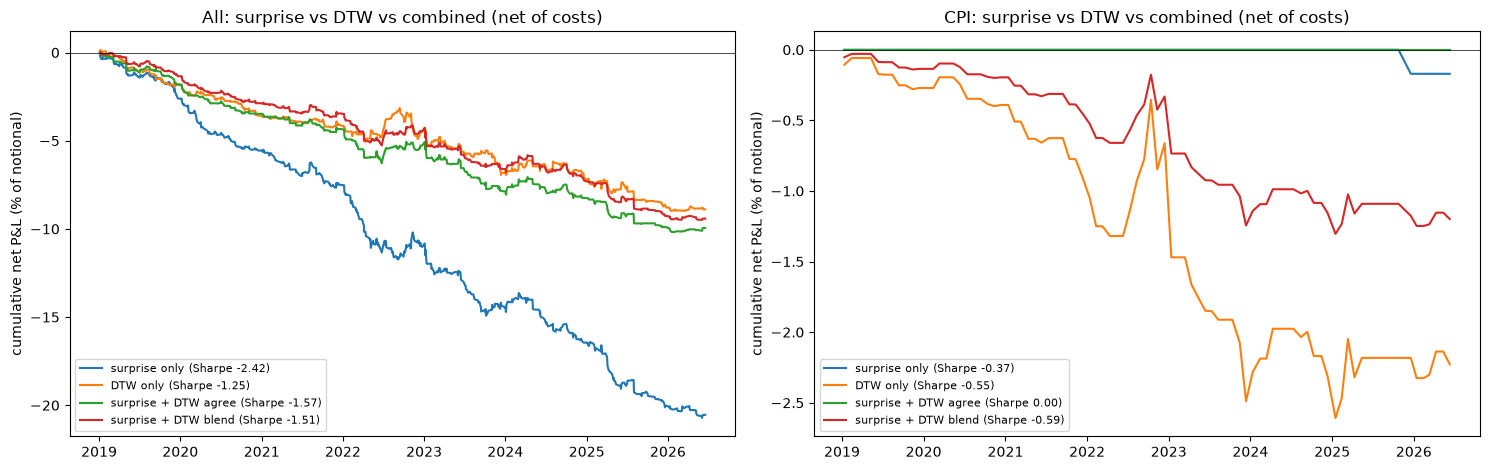

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharey=False)
for ax, tag in zip(axes, ["All", "CPI"]):
    for i, suffix in enumerate(["surprise only", "DTW only", "surprise + DTW agree", "surprise + DTW blend"]):
        s = f"{tag} · {suffix}"
        cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
        ax.plot(cum.index, cum.values, lw=1.5, label=f"{suffix} (Sharpe {perf.loc[s, 'sharpe_net']:.2f})")
    ax.axhline(0, c="k", lw=0.5)
    ax.set_title(f"{tag}: surprise vs DTW vs combined (net of costs)")
    ax.set_ylabel("cumulative net P&L (% of notional)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_cumulative_pnl.png", dpi=150); plt.show()

### 7.4 When surprise and DTW disagree

In [13]:
t = attach(base_all)
t = t[(t["position"] != 0) & t["dtw_dir"].notna()]
t["net"] = t["position"] * t["ret_bps"] - t["cost_bps"]
t["dtw_agrees"] = np.sign(t["dtw_dir"]) == np.sign(t["position"])
agree_tab = t.groupby("dtw_agrees")["net"].agg(trades="size", hit_rate=lambda v: (v > 0).mean(),
                                               avg_net_bps="mean", total_net_pct=lambda v: v.sum() / 100)
display(agree_tab.round(3))

,trades,hit_rate,avg_net_bps,total_net_pct
dtw_agrees,,,,
False,307,0.339,-3.530,-10.591
True,318,0.368,-3.205,-10.032


If DTW adds information, surprise trades where **DTW agrees** should clearly beat those where it **disagrees**. Similar numbers in both rows mean DTW is not separating good trades from bad ones.

## 8. Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern

In [14]:
rows_f = []
if NB04_FINAL.exists():
    f4 = pd.read_csv(NB04_FINAL, index_col=[0, 1])
    for strat, label in [("Surprise only", "Surprise only — CPI (NB04)"),
                         ("Surprise + State", "Surprise + State — CPI (NB04)"),
                         ("Surprise + Adaptive state", "Surprise + Adaptive state — CPI (NB04)")]:
        if ("CPI", strat) in f4.index:
            r = f4.loc[("CPI", strat)]
            rows_f.append(dict(model=label, trades_per_year=r["trades"] / N_YEARS, net_bps_per_trade=r["avg_net_bps"],
                               sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"]))
for s, label in [("All · surprise only", "Surprise only — ~10 releases (NB05)"),
                 ("CPI · surprise only", "Surprise only — CPI model (NB05)"),
                 ("All · surprise + DTW agree", "Surprise + Pattern (agree) — ~10 releases"),
                 ("All · surprise + DTW blend", "Surprise + Pattern (blend) — ~10 releases"),
                 ("CPI · surprise + DTW agree", "Surprise + Pattern (agree) — CPI"),
                 ("All · DTW only", "Pattern only (DTW) — ~10 releases")]:
    r = perf.loc[s]
    rows_f.append(dict(model=label, trades_per_year=r["trades_per_year"], net_bps_per_trade=r["avg_net_bps"],
                       sharpe_net=r["sharpe_net"], max_dd_pct=r["max_dd_pct"],
                       sharpe_ex_2022=rob.loc[s, "sharpe_ex_2022"], p_random_sign=rob.loc[s, "p_random_sign"]))
rows_f.append(dict(model="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, net_bps_per_trade=1.18,
                   sharpe_net=0.613, max_dd_pct=-4.928))
final = pd.DataFrame(rows_f).set_index("model")
final.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_final_three_model_comparison.csv")
display(final.round(3))

,trades_per_year,net_bps_per_trade,sharpe_net,max_dd_pct,sharpe_ex_2022,p_random_sign
model,,,,,,
Surprise only — CPI (NB04),0.267,-3.225,-0.509,-0.065,NaN,NaN
Surprise + State — CPI (NB04),0.667,-3.563,-0.403,-0.254,NaN,NaN
Surprise + Adaptive state — CPI (NB04),0.267,-3.225,-0.509,-0.065,NaN,NaN
Surprise only — ~10 releases (NB05),81.938,-3.346,-2.422,-20.564,-2.534,0.812
Surprise only — CPI model (NB05),0.133,-17.033,-0.365,-0.170,-0.392,1.000
Surprise + Pattern (agree) — ~10 releases,41.770,-3.180,-1.568,-10.179,-1.893,0.645
Surprise + Pattern (blend) — ~10 releases,62.854,-1.999,-1.511,-9.492,-1.716,0.395
Surprise + Pattern (agree) — CPI,0.000,NaN,0.000,0.000,NaN,0.000
Pattern only (DTW) — ~10 releases,55.114,-2.154,-1.250,-9.150,-1.707,0.164


### 8.1 Automatic summary

In [15]:
print("=" * 100)
print(f"NOTEBOOK 06 SUMMARY — does DTW add to the surprise? ({MARKET}, 2019-2026, net of costs)")
print("=" * 100)
print("DTW directional information (rank IC vs 30-min return):")
for k, r in diag.iterrows():
    print(f"  {k:<28s} n={int(r.n):>5d}  rank IC={r.rank_ic:+.4f}  hit={r.hit_sign:.1%}")
print()
for s in STRATS:
    r = perf.loc[s]; q = rob.loc[s]
    extra = "" if pd.isna(q.get("p_not_better", np.nan)) else f" | vs surprise: ΔSharpe {q['sharpe_diff_vs_surprise']:+.2f}, P(not better) {q['p_not_better']:.2f}"
    print(f"{s:<32s} {r.trades_per_year:5.0f} tr/yr | Sharpe {r.sharpe_net:5.2f} | {r.avg_net_bps:6.2f} bps | "
          f"random-sign p {q['p_random_sign']:.3f}{extra}")

NOTEBOOK 06 SUMMARY — does DTW add to the surprise? (ZN, 2019-2026, net of costs)
DTW directional information (rank IC vs 30-min return):
  all releases 2019-26         n= 4106  rank IC=+0.0393  hit=46.6%
  NB05 traded releases         n=  664  rank IC=+0.0397  hit=47.9%
  08:30 releases               n= 1095  rank IC=+0.0032  hit=46.5%
  10:00 releases               n= 1016  rank IC=+0.0480  hit=46.8%

All · surprise only                 82 tr/yr | Sharpe -2.42 |  -3.35 bps | random-sign p 0.812
All · DTW only                      55 tr/yr | Sharpe -1.25 |  -2.15 bps | random-sign p 0.164 | vs surprise: ΔSharpe +1.17, P(not better) 0.02
All · surprise + DTW agree          42 tr/yr | Sharpe -1.57 |  -3.18 bps | random-sign p 0.645 | vs surprise: ΔSharpe +0.85, P(not better) 0.01
All · surprise + DTW blend          63 tr/yr | Sharpe -1.51 |  -2.00 bps | random-sign p 0.395 | vs surprise: ΔSharpe +0.91, P(not better) 0.00
CPI · surprise only                  0 tr/yr | Sharpe -0.37 | -17.

## 9. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Does DTW predict direction by itself?** Use the rank IC (Section 5.1) and the DTW-only strategy.

**2. Is DTW just re-measuring the surprise?** Use the correlation between the DTW score and the surprise (Section 5.2).

**3. Does DTW improve the surprise strategy?** Compare the agreement and blend strategies with surprise only: Sharpe difference, `P(not better)`, and agree-vs-disagree trades (Section 7.4).

**4. Final three-model answer.** Surprise only vs Surprise + State vs Surprise + Pattern: which one would you recommend, and how confident are you?

# 10. Extra Test: The Ladder: Can We Reach ~185 Trades a Year?

## Why this test

The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES** because it takes **five consecutive 30-minute trades after each release** (T+1, T+31, T+61, T+91, T+121). Our books take **one trade per release**, which caps them at about 108 trades a year on our universe.

This section copies the ladder structure to answer the supervisor's question directly:

> **If we trade five windows after each release, how many trades do we get, and what happens to the Sharpe?**

## Design (fixed before running)

| Window | Entry → exit (bars after the release) | Approx. clock time for an 08:30 release |
|---|---|---|
| 1 | close of bar T → T+29 (same as Sections 1–9) | 08:31 → 09:00 |
| 2 | T+29 → T+59 | 09:00 → 09:30 |
| 3 | T+59 → T+89 | 09:30 → 10:00 |
| 4 | T+89 → T+119 | 10:00 → 10:30 |
| 5 | T+119 → T+149 | 10:30 → 11:00 |

- **Releases:** the same ~108 release timestamps a year as Notebook 05's multi-release book.
- **DTW for window k:** the 31-minute path ending at **that window's entry**, matched against earlier releases at the same clock time, with the neighbours' **window-k** returns as the answer. Neighbours must have finished window k before the current release. The same k = 15, band, lookback, weights and middle-40% gate apply, with the gate computed separately for each window.
- **Surprise for window k:** the sign of the release's surprise (Notebook 05 naive rule), held for that window.
- **Costs:** the same round-trip cost for every window.

**Three books:**
1. **DTW ladder:** DTW in all five windows (closest to the peer structure).
2. **Surprise ladder:** the surprise sign in all five windows.
3. **Surprise W1 + DTW W2–5:** the surprise for the first window, then DTW for the later ones.

**Expected result (stated before running):** Notebook 05 found the surprise's effect is gone within about 30 minutes (window 2 Sharpe −0.79), and Section 5 found no DTW direction in window 1. We therefore expect the trade count to reach the peer's level while the Sharpe falls toward zero.

**Note:** later windows of an 08:30 release can overlap the first window of a 10:00 release on the same day. Each window is treated as a separate trade on one contract, as in the peer strategy.

## 10.1 Window returns and DTW signals for each window

In [16]:
t0 = time.time()
lad = ds.ladder_returns(es_adj, cal["ts_utc"])
assert np.nanmax(np.abs(lad["r1"].to_numpy() - cal["w1"].to_numpy())) < 1e-9, "window 1 must equal w1"
print("Window 1 identical to the Sections 1-9 trade return: OK")

sigs, lgates = {}, {}
for k, (a, b) in enumerate(ds.LADDER, start=1):
    raw_k = ds.extract_paths(es_adj, cal["ts_utc"], end_offset_min=a)
    paths_k = ds.zscore_rows(raw_k)
    sigs[k] = ds.compute_dtw_signal(cal["ts_utc"], cal["clock_et"].to_numpy(), paths_k, lad[f"r{k}"].to_numpy(),
                                    query_mask=qmask, lookback_years=LOOKBACK_YEARS, max_pool=MAX_POOL,
                                    k=K_NN, band=BAND, half_life_years=HALF_LIFE, progress_every=0,
                                    min_gap_min=b + 1)
    lgates[k] = ds.gate_thresholds(sigs[k], EVAL_YEARS, window_years=3, middle=GATE_MIDDLE)
    print(f"Window {k} (bars {a:>3d} -> {b:>3d}): DTW computed for {sigs[k]['dtw_dir'].notna().sum():,} releases")
print(f"Done in {time.time()-t0:.0f}s")

Window 1 identical to the Sections 1-9 trade return: OK
Window 1 (bars   0 ->  29): DTW computed for 5,244 releases
Window 2 (bars  29 ->  59): DTW computed for 5,233 releases
Window 3 (bars  59 ->  89): DTW computed for 5,131 releases
Window 4 (bars  89 -> 119): DTW computed for 5,123 releases
Window 5 (bars 119 -> 149): DTW computed for 5,017 releases
Done in 21s


## 10.2 Build the ladder books

In [17]:
uni = base_all[["timestamp_utc", "position", "x", "cost_bps"]].rename(columns={"position": "surp_pos"})

def window_trades(k, rule):
    a, b = ds.LADDER[k - 1]
    t = uni.merge(lad[["ts_utc", f"r{k}"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t = t.merge(sigs[k][["ts_utc", "dtw_dir", "dtw_score"]], left_on="timestamp_utc", right_on="ts_utc", how="left").drop(columns="ts_utc")
    t["ret_bps"] = t[f"r{k}"]
    if rule == "dtw":
        y = t["timestamp_utc"].dt.tz_convert("America/New_York").dt.year
        lo = y.map(lambda v: lgates[k][v][0]); hi = y.map(lambda v: lgates[k][v][1])
        s = t["dtw_score"]
        t["position"] = np.where((s < lo) | (s > hi), np.sign(s), 0.0)
        t["position"] = pd.Series(t["position"]).fillna(0.0).to_numpy()
    else:
        t["position"] = t["surp_pos"]
    t["eligible"] = t["ret_bps"].notna()
    t["release_ts"] = t["timestamp_utc"]
    t["timestamp_utc"] = t["timestamp_utc"] + pd.Timedelta(minutes=a + 1)   # when the trade is entered
    t["window"] = k
    return ds.recost(t, f"{rule} W{k}")

W = {(rule, k): window_trades(k, rule) for rule in ["dtw", "surprise"] for k in range(1, 6)}

def book(parts, name):
    return ds.recost(pd.concat(parts).sort_values("timestamp_utc").reset_index(drop=True), name)

L = {
    "Surprise W1 only (Sections 1-9)": W[("surprise", 1)].assign(strategy="Surprise W1 only (Sections 1-9)"),
    "DTW ladder (5 windows)": book([W[("dtw", k)] for k in range(1, 6)], "DTW ladder (5 windows)"),
    "Surprise ladder (5 windows)": book([W[("surprise", k)] for k in range(1, 6)], "Surprise ladder (5 windows)"),
    "Surprise W1 + DTW W2-5": book([W[("surprise", 1)]] + [W[("dtw", k)] for k in range(2, 6)], "Surprise W1 + DTW W2-5"),
}
pd.concat(L.values()).to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_trade_log.csv", index=False)

## 10.3 Results by window

rank_ic          trades_per_year          avg_net_bps          sharpe_net         
rule                      dtw surprise             dtw surprise         dtw surprise        dtw surprise
window bars                                                                                             
1      T+0 -> T+29      0.040   -0.026          55.114   81.938      -2.154   -3.346     -1.250   -2.422
2      T+29 -> T+59    -0.015   -0.011          52.312   81.938      -2.810   -3.145     -1.944   -3.077
3      T+59 -> T+89    -0.019    0.010          56.049   81.938      -3.126   -2.788     -2.337   -3.147
4      T+89 -> T+119    0.011   -0.044          52.312   81.938      -2.364   -3.582     -1.617   -3.900
5      T+119 -> T+149  -0.010    0.038          51.511   81.938      -3.045   -2.789     -2.924   -3.559

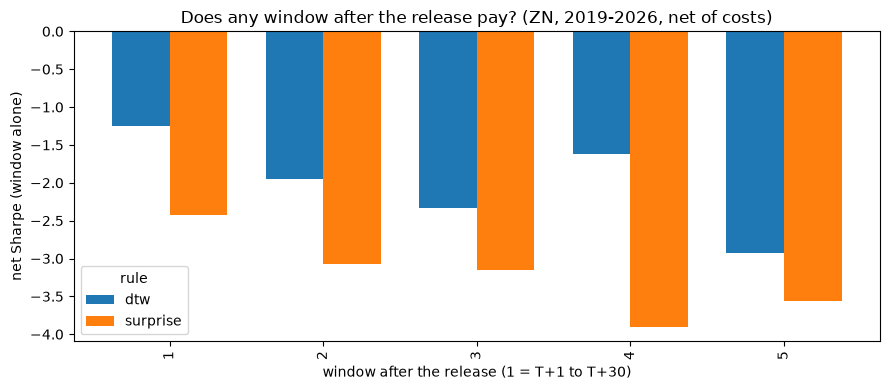

In [18]:
rows_w = []
for k in range(1, 6):
    for rule in ["surprise", "dtw"]:
        t = W[(rule, k)]
        p = wf.performance(t, EVAL_START, EVAL_END, f"{rule} W{k}")
        e = t[t["eligible"] & (t["release_ts"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
        ic = e["dtw_score"].corr(e["ret_bps"], method="spearman") if rule == "dtw" else e["x"].corr(e["ret_bps"], method="spearman")
        rows_w.append(dict(window=k, rule=rule, bars=f"T+{ds.LADDER[k-1][0]} -> T+{ds.LADDER[k-1][1]}",
                           rank_ic=ic, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                           avg_net_bps=p["avg_net_bps"], sharpe_net=p["sharpe_net"], total_net_pct=p["total_net_pct"]))
by_window = pd.DataFrame(rows_w)
by_window.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_by_window.csv", index=False)
display(by_window.pivot(index=["window", "bars"], columns="rule",
                        values=["rank_ic", "trades_per_year", "avg_net_bps", "sharpe_net"]).round(3))

fig, ax = plt.subplots(figsize=(9, 4))
piv = by_window.pivot(index="window", columns="rule", values="sharpe_net")
piv.plot.bar(ax=ax, width=0.75)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net Sharpe (window alone)")
ax.set_xlabel("window after the release (1 = T+1 to T+30)")
ax.set_title(f"Does any window after the release pay? ({MARKET}, 2019-2026, net of costs)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_ladder_sharpe_by_window.png", dpi=150); plt.show()

**How to read it.** Window 1 is the trade used in Sections 1–9. If the ladder were worth trading, windows 2–5 would show positive Sharpe and a positive rank IC. For the surprise, the rank IC is the correlation between the surprise and that window's return.

## 10.4 Ladder books: trade count vs Sharpe

,trades_per_year,hit_rate,avg_net_bps,total_net_pct,sharpe_net,sharpe_ex_2022,max_dd_pct,p_random_sign
book,,,,,,,,
Surprise W1 only (Sections 1-9),81.938,0.362,-3.346,-20.543,-2.422,-2.534,-20.564,0.812
DTW ladder (5 windows),267.298,0.324,-2.699,-54.061,-3.921,-4.590,-54.160,0.098
Surprise ladder (5 windows),409.689,0.305,-3.130,-96.088,-7.653,-8.315,-96.099,0.996
Surprise W1 + DTW W2-5,294.122,0.317,-2.981,-65.710,-5.354,-6.274,-65.553,0.887
"Peer: Jack DTW (slide, 2018-26)",185.000,NaN,1.180,18.597,0.613,NaN,-4.928,NaN


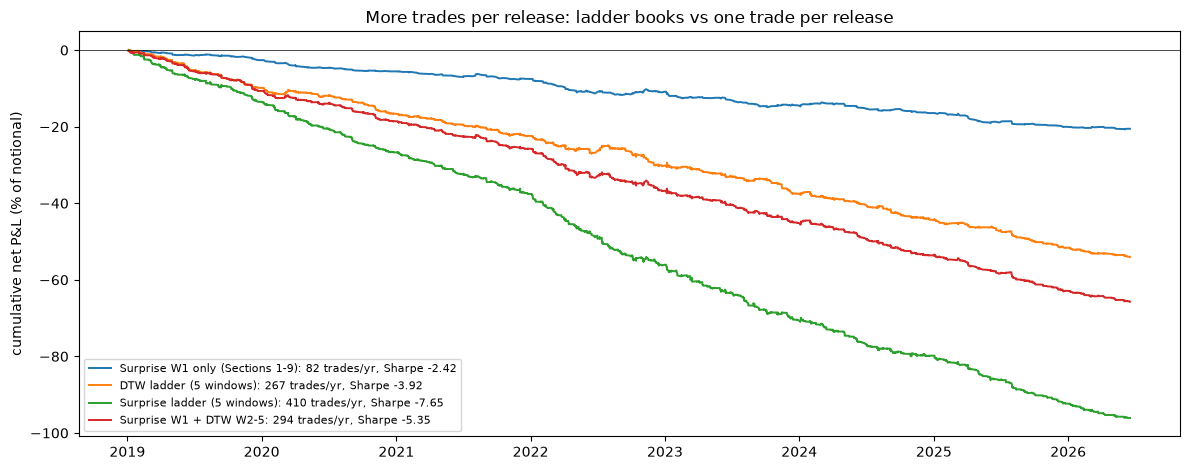

In [19]:
rows_b = []
for name, t in L.items():
    p = wf.performance(t, EVAL_START, EVAL_END, name)
    obs, p_null = su.random_sign_pvalue(t, wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    rows_b.append(dict(book=name, trades_per_year=p["trades"] / N_YEARS, hit_rate=p["hit_rate"],
                       avg_net_bps=p["avg_net_bps"], total_net_pct=p["total_net_pct"],
                       sharpe_net=p["sharpe_net"], sharpe_ex_2022=sharpe_m(t, EVAL_START, EVAL_END, 2022),
                       max_dd_pct=p["max_dd_pct"], p_random_sign=p_null))
rows_b.append(dict(book="Peer: Jack DTW (slide, 2018-26)", trades_per_year=185, avg_net_bps=1.18,
                   total_net_pct=18.597, sharpe_net=0.613, max_dd_pct=-4.928))
ladder_tab = pd.DataFrame(rows_b).set_index("book")
ladder_tab.to_csv(RESULTS_DIR / f"nb06b_{MARKET}_ladder_books.csv")
display(ladder_tab.round(3))

fig, ax = plt.subplots(figsize=(12, 4.8))
for name, t in L.items():
    cum, _ = wf.drawdown_series(t, EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, lw=1.4,
            label=f"{name}: {ladder_tab.loc[name, 'trades_per_year']:.0f} trades/yr, Sharpe {ladder_tab.loc[name, 'sharpe_net']:.2f}")
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title("More trades per release: ladder books vs one trade per release")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb06b_{MARKET}_ladder_cumulative.png", dpi=150); plt.show()

## 10.5 Summary of the ladder test

In [20]:
print("=" * 100)
print(f"LADDER TEST — five 30-minute windows per release ({MARKET}, 2019-2026, net of costs)")
print("=" * 100)
print("By window (net Sharpe of that window alone):")
for k in range(1, 6):
    s = by_window[(by_window.window == k) & (by_window.rule == "surprise")].iloc[0]
    d = by_window[(by_window.window == k) & (by_window.rule == "dtw")].iloc[0]
    print(f"  W{k} {s.bars:<16s} surprise: IC {s.rank_ic:+.3f}, Sharpe {s.sharpe_net:+.2f} | "
          f"DTW: IC {d.rank_ic:+.3f}, Sharpe {d.sharpe_net:+.2f}, {d.trades_per_year:.0f} tr/yr")
print("\nBooks:")
for name, r in ladder_tab.iterrows():
    print(f"  {name:<34s} {r.trades_per_year:6.0f} trades/yr | {r.avg_net_bps:6.2f} bps/trade | "
          f"Sharpe {r.sharpe_net:5.2f} | maxDD {r.max_dd_pct:6.2f}%")

LADDER TEST — five 30-minute windows per release (ZN, 2019-2026, net of costs)
By window (net Sharpe of that window alone):
  W1 T+0 -> T+29      surprise: IC -0.026, Sharpe -2.42 | DTW: IC +0.040, Sharpe -1.25, 55 tr/yr
  W2 T+29 -> T+59     surprise: IC -0.011, Sharpe -3.08 | DTW: IC -0.015, Sharpe -1.94, 52 tr/yr
  W3 T+59 -> T+89     surprise: IC +0.010, Sharpe -3.15 | DTW: IC -0.019, Sharpe -2.34, 56 tr/yr
  W4 T+89 -> T+119    surprise: IC -0.044, Sharpe -3.90 | DTW: IC +0.011, Sharpe -1.62, 52 tr/yr
  W5 T+119 -> T+149   surprise: IC +0.038, Sharpe -3.56 | DTW: IC -0.010, Sharpe -2.92, 52 tr/yr

Books:
  Surprise W1 only (Sections 1-9)        82 trades/yr |  -3.35 bps/trade | Sharpe -2.42 | maxDD -20.56%
  DTW ladder (5 windows)                267 trades/yr |  -2.70 bps/trade | Sharpe -3.92 | maxDD -54.16%
  Surprise ladder (5 windows)           410 trades/yr |  -3.13 bps/trade | Sharpe -7.65 | maxDD -96.10%
  Surprise W1 + DTW W2-5                294 trades/yr |  -2.98 bps/trad

### 10.6 Interpretation (fill in after running)

**1. Trade count:** how close does each ladder book get to the peer's 185 trades a year?

**2. Which windows pay?** Is window 1 the only one with a positive edge, for the surprise and for DTW?

**3. Trade count vs Sharpe:** does adding windows raise or lower the Sharpe compared with one trade per release (Sharpe 0.65 at ~98 trades a year)?

**4. Answer for the supervisor:** can we honestly reach ~185 trades a year, and at what cost in risk-adjusted return?

# Purpose, Research Questions, Answers, and Conclusion (ZN)

## Purpose of Notebook 06b (ZN)

Notebooks 04b and 05b showed that no surprise strategy is profitable on ZN, because the bond market prices the surprise in the first minute and the ZN cost is about 3 bps per round trip.

Notebook 06b repeats Notebook 06 on ZN:

> **Can the shape of ZN's price path around a release give a directional signal that the surprise does not?**

**Design (identical to Notebook 06):** the peer DTW specification, built on **ZN prices**, with the releases, entry (T+1), exit (T+30), costs and evaluation window (2019–2026) of Notebook 05b.

**Checks:** every Notebook 05b release was found, with identical trade returns (difference 3.6×10⁻¹⁵ bps).

---

## Research Questions and Answers

### Section 4: Can a DTW signal be built for every release?
**Answer:** Yes. DTW was computed for **5,244 releases**, each matched against an average of about 378 earlier releases at the same clock time.

### Section 5.1: Does DTW predict the 30-minute return by itself?
**Answer:** **Weakly at best.**

| Sample (2019–2026) | Releases | Rank IC | Hit rate |
|---|---|---|---|
| All releases | 4,106 | +0.039 | 46.6% |
| Releases traded in Notebook 05b | 664 | +0.040 | 47.9% |
| 08:30 releases | 1,095 | +0.003 | 46.5% |
| 10:00 releases | 1,016 | +0.048 | 46.8% |

The rank IC is the highest of the three markets (+0.04) and is positive in 6 of 8 years (up to +0.085 in 2026). But the **sign hit rate is below 50%**: the ranking contains a little information about large moves, but the sign alone does not.

### Section 5.2: Is DTW just re-measuring the surprise?
**Answer:** **No.** The correlation between the DTW score and the surprise is **0.02**, and they agree in direction on **47%** of releases.

### Section 6: How often does each model trade?
**Answer:** The multi-release books trade 42–84 times a year. On CPI the surprise model traded **once** in 7.5 years (its predicted move almost never exceeds the 3 bps cost), so the CPI "surprise + DTW agree" book has **no trades**.

### Section 7.1: Does adding DTW improve the surprise strategy?

**All ~10 releases:**

| Strategy | Trades / yr | Gross bps / trade | Net bps / trade | Net Sharpe | Max DD | Δ Sharpe vs surprise | P(not better) |
|---|---|---|---|---|---|---|---|
| Surprise only | 82 | −0.42 | −3.35 | −2.42 | −20.6% | — | — |
| Surprise + DTW agree | 42 | −0.23 | −3.18 | −1.57 | −10.2% | +0.85 | 0.01 |
| Surprise + DTW blend | 63 | +0.09 | −2.00 | −1.51 | −9.5% | +0.91 | 0.00 |
| **DTW only** | 55 | **+0.82** | −2.15 | −1.25 | −9.2% | +1.17 | 0.02 |

**CPI only:**

| Strategy | Trades / yr | Net bps / trade | Net Sharpe |
|---|---|---|---|
| Surprise model | 0.1 (1 trade) | −17.0 | −0.37 |
| DTW only | 7 | −4.2 | −0.55 |
| Surprise + DTW blend | 7 | −2.2 | −0.59 |
| Surprise + DTW agree | 0 | — | — |

**Answer:** Every ZN book **loses money after costs**. DTW books lose **significantly less** than surprise only (P(not better) ≤ 0.02), but mainly because they **trade less**: fewer trades means less cost paid. DTW only is the only book with a positive gross return (+0.8 bps per trade, gross Sharpe 0.47), far below the 3 bps cost.

### Section 7.2: Is it robust?
**Answer:** No ZN book beats random directions (random-sign p from 0.16 to 0.81). The DTW-only book comes closest (p = 0.16).

### Section 7.4: Does DTW separate good surprise trades from bad ones?
**Answer:** **No.** Surprise trades where DTW agreed lost −3.2 bps per trade (318 trades), and those where it disagreed −3.5 bps (307 trades). Both lose about the cost.

---

## Final Comparison: Surprise Only vs Surprise + State vs Surprise + Pattern (ZN)

| Model | Trades / yr | Net bps / trade | Net Sharpe | Max DD |
|---|---|---|---|---|
| Surprise only, CPI (NB04b) | 0.3 | −3.2 | −0.51 | −0.1% |
| Surprise + State, CPI (NB04b) | 0.7 | −3.6 | −0.40 | −0.3% |
| Surprise only, ~10 releases (NB05b) | 82 | −3.3 | −2.42 | −20.6% |
| Surprise + Pattern (blend), ~10 releases | 63 | −2.0 | −1.51 | −9.5% |
| Surprise + Pattern (agree), ~10 releases | 42 | −3.2 | −1.57 | −10.2% |
| Pattern only (DTW), ~10 releases | 55 | −2.2 | −1.25 | −9.2% |
| *Peer: Jack DTW (slide, ES, 2018–26)* | *185* | *1.2* | *0.61* | *−4.9%* |

---

# 10. The Ladder: Can We Reach ~185 Trades a Year? (ZN)

### Section 10.3: Which windows after the release pay?

| Window | Surprise: rank IC | Surprise: net Sharpe | DTW: rank IC | DTW: net Sharpe |
|---|---|---|---|---|
| 1: T+1 → T+30 | −0.026 | −2.42 | +0.040 | −1.25 |
| 2: T+30 → T+60 | −0.011 | −3.08 | −0.015 | −1.94 |
| 3: T+60 → T+90 | +0.010 | −3.15 | −0.019 | −2.34 |
| 4: T+90 → T+120 | −0.044 | −3.90 | +0.011 | −1.62 |
| 5: T+120 → T+150 | +0.038 | −3.56 | −0.010 | −2.92 |

**Answer:** **No window pays.** Neither signal has information in any window (all rank ICs between −0.04 and +0.04), and every window loses about the cost on every trade.

### Section 10.4: What happens to trade count and Sharpe?

| Book | Trades / yr | Net bps / trade | Total net P&L | Net Sharpe | Max DD |
|---|---|---|---|---|---|
| Surprise, window 1 only | 82 | −3.35 | −20.5% | −2.42 | −20.6% |
| DTW ladder (5 windows) | 267 | −2.70 | −54.1% | −3.92 | −54.2% |
| Surprise W1 + DTW W2–5 | 294 | −2.98 | −65.7% | −5.35 | −65.6% |
| Surprise ladder (5 windows) | 410 | −3.13 | −96.1% | −7.65 | −96.1% |

**Answer:** On ZN, more windows simply mean paying the 3 bps cost more often. The ladder books lose between 54% and 96% of notional over 7.5 years.

---

## Conclusion (ZN)

**1. There is no tradeable directional signal on ZN after the first minute.** Neither the surprise nor DTW predicts the 30-minute return well enough to cover the cost, in any window.

**2. DTW is the "least bad" ZN signal, not a good one.** It has the highest rank IC of the three markets (+0.04) and a small positive gross return (+0.8 bps per trade), but it loses −2.2 bps per trade after costs. It beats the surprise on ZN only because it trades less.

**3. More windows make it much worse.** Every ladder book loses more than half of notional.

**4. Recommendation for ZN: do not trade.** ZN reacts to macro surprises in the economically expected direction, but the reaction is complete within the first minute. At an executable entry and about 3 bps per round trip, no surprise, pattern or ladder strategy is profitable.

> **Overall:** ZN completes the cross-market picture. The macro-surprise edge exists only in **equity index futures** (ES, NQ), where a post-release drift remains for about 30 minutes. In the bond market the surprise is priced in the first minute, and neither the surprise nor the DTW pattern leaves anything to trade.